In [1]:
# q 7.1

import numpy as np
from numpy import linalg as la

# 1. Determinant
A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
det = la.det(A)

print(f"The determinant of A is: {det:.2f}")

# 2. Solution to set of eqs (coeffs. of matrix)
b = np.array([2,2,-1])
Ainv = la.inv(A)
xyz = Ainv@b

print(f"The solutions to x,y,z are: {xyz}")

# 3. Is A orthogonal? A n x n matrix is orthogonal if A.AT = I , from this we can derive that A**(-1) = A.T
print(f"\nA.T should be the identity matrix: \n{A.T}\n{A@A.T == np.identity(3)}")
print()
print(f"As the equality doesn't hold A isn't orthogonal")

print()

# 4. Eigenvalues of A
Lambda, v = la.eig(A)
print(f"The eigenvalues are: {Lambda}")
print(f"\nThe eigenvectors are:\n{v}") 


The determinant of A is: 1.00
The solutions to x,y,z are: [10. -1. -2.]

A.T should be the identity matrix: 
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]
[[False False False]
 [False False False]
 [False False False]]

As the equality doesn't hold A isn't orthogonal

The eigenvalues are: [ 1.         -4.79128785 -0.20871215]

The eigenvectors are:
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [2]:
# 7.2

import numpy as np
from numpy import sin, cos
from numpy import linalg as la

def Ex(deg):
    rad = np.radians(deg) # Convert angle to radians
    matrix = np.array([1, 0, 0, 0, cos(rad), sin(rad), 0, -sin(rad), cos(rad)]).reshape(3,3)
    
    return matrix

def Ey(deg):
    rad = np.radians(deg)
    matrix = np.array([cos(rad), 0, -sin(rad), 0 , 1, 0, sin(rad), 0, cos(rad)]).reshape(3,3)
    
    return matrix  

def Ez(deg):
    rad = np.radians(deg)
    matrix = np.array([cos(rad), sin(rad), 0, -sin(rad), cos(rad), 0, 0, 0, 1]).reshape(3,3)
    
    return matrix
    


print(f"\nEx(33)=\n{Ex(33)}")
print(f"\nEy(33)=\n{Ey(33)}")
print(f"\nEz(33)=\n{Ez(33)}")


Ex(33)=
[[ 1.          0.          0.        ]
 [ 0.          0.83867057  0.54463904]
 [ 0.         -0.54463904  0.83867057]]

Ey(33)=
[[ 0.83867057  0.         -0.54463904]
 [ 0.          1.          0.        ]
 [ 0.54463904  0.          0.83867057]]

Ez(33)=
[[ 0.83867057  0.54463904  0.        ]
 [-0.54463904  0.83867057  0.        ]
 [ 0.          0.          1.        ]]


In [23]:
# q 7.3

import numpy as np
from numpy import linalg as la
from numpy import sin, cos
from numpy.linalg import norm

angle_z1 = 180-123
angle_y = 90-27.4
angle_z2 = 192.25

def calculate_E():
    
    rad_z1 = np.radians(angle_z1)
    rad_y = np.radians(angle_y)
    rad_z2 = np.radians(angle_z2)

    Ez1 = np.array([cos(rad_z1), sin(rad_z1), 0, -sin(rad_z1), cos(rad_z1), 0, 0, 0, 1]).reshape(3,3)
    Ey = np.array([cos(rad_y), 0, -sin(rad_y), 0 , 1, 0, sin(rad_y), 0, cos(rad_y)]).reshape(3,3)
    Ez2 = np.array([cos(rad_z2 ), sin(rad_z2 ), 0, -sin(rad_z2 ), cos(rad_z2 ), 0, 0, 0, 1]).reshape(3,3)
   
    E = Ez1@Ey@Ez2

    return E

result = calculate_E()
print(result)
print()

# Prove that it is a rotation matrix if R.T = R**(-1) and det(R) = 1
det = la.det(result)
print(f"The calculated matrix is a rotation matrix as it's determinant = {det}")
print()

# Prove that E has an eigenvalue lambda=1

Lambda, v = la.eig(result)
print(Lambda)


# Galactic pole

def calculate_v(alpha, phi):
    alpha_deg = np.radians(alpha)
    phi_deg = np.radians(phi)
    
    matrix = np.array([cos(phi_deg)*cos(alpha_deg), cos(phi_deg)*sin(alpha_deg), sin(phi_deg)]).reshape(3, 1)
    return matrix

E = result # A la matriz E le cambio el nombre de result a E 

result = calculate_v(192.25, 27.4)

print(E@result) 
print()
print(f"\n{result}")
print()

# norm of v 
L = norm(result)
print(f"The norm of v = {L}")


[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

The calculated matrix is a rotation matrix as it's determinant = 1.0

[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
[[2.77555756e-17]
 [5.55111512e-17]
 [1.00000000e+00]]


[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]

The norm of v = 1.0


In [4]:
# 7.4 import numpy as np

import numpy as np

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

# Algorithm for linear interpolation (interpolated value: y_hat for a given x_hat)

x_hat = float(input(f"Input value for x_hat:"))

for i in range(len(x)):
    if x[i] > x_hat:
        
        # define values
        x1 = x[i-1]
        x2 = x[i]
        y1 = y[i-1]
        y2 = y[i]

        # interpolation function

        numerator = (y2 - y1)*(x_hat - x1)
        denominator = (x2 - x1)
    
        y_hat = y1 + numerator/denominator

        break
    
print(f"The interpolated value is: {y_hat}")

# Check with np.interp
print(np.interp(2.5, x, y))

Input value for x_hat: 2.5


The interpolated value is: 0.5909090909090908
0.5909090909090908


The coefficients matrix is: 
[ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331360e+01  2.91867715e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


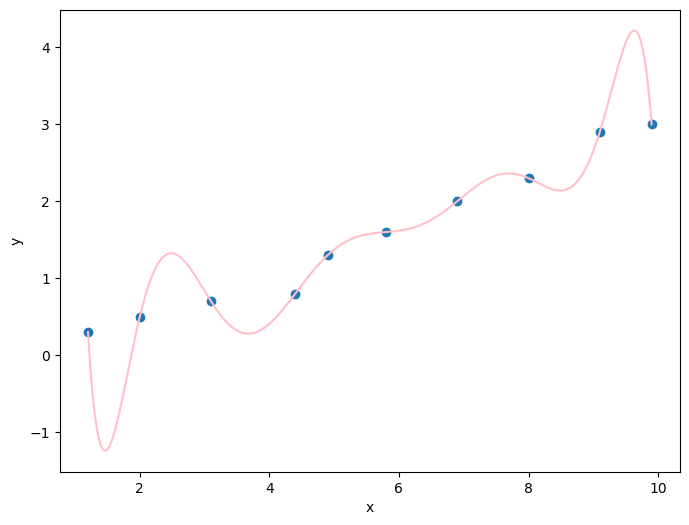

In [4]:
# q 7.5 

import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

N = len(x)
A = np.zeros((N, N)) # Initialise array of size NxN

for i in range(N):
    for j in range (N):
        A[i, j] = x[i]**j

# Now we have filled the matrix, the next step is to solve Aa = y for the coeffs 'a' (= coefficients of the interpolating polynomial that goes through all the data points)
a = np.linalg.solve(A, y)
print (f"The coefficients matrix is: \n{a}")

# Plot of the data and interpolating polynomial.
x_plot = np.linspace(1.2, 9.9, 500)
# To get the values for y we can use np.polyval(p, x)
# Where p are the coeffs (expected in decreasing order, and x is an array)
reversed_coeffs = a[::-1]
y_plot = np.polyval(reversed_coeffs, x_plot)

plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.plot(x_plot, y_plot, color='pink')
plt.xlabel('x')
plt.ylabel('y')

plt.show()







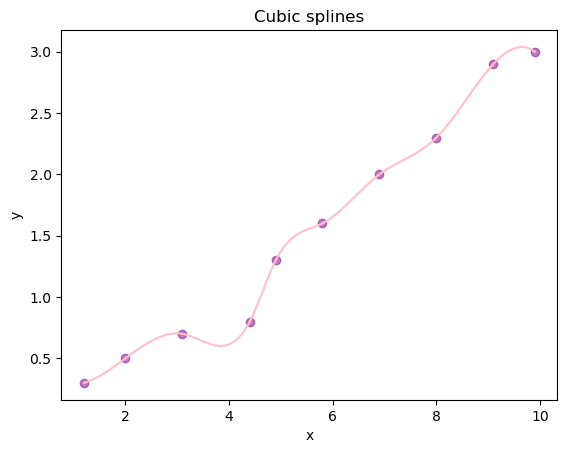

[0.3        0.3219697  0.34393939 0.36590909 0.38787879 0.40984848
 0.43181818 0.45378788 0.47575758 0.49772727 0.51432507 0.53030303
 0.54628099 0.56225895 0.57823691 0.59421488 0.61019284 0.6261708
 0.64214876 0.65812672 0.67410468 0.69008264 0.7025641  0.70932401
 0.71608392 0.72284382 0.72960373 0.73636364 0.74312354 0.74988345
 0.75664336 0.76340326 0.77016317 0.77692308 0.78368298 0.79044289
 0.7972028  0.85151515 0.93939394 1.02727273 1.11515152 1.2030303
 1.29090909 1.32626263 1.35555556 1.38484848 1.41414141 1.44343434
 1.47272727 1.5020202  1.53131313 1.56060606 1.58989899 1.62093664
 1.65289256 1.68484848 1.71680441 1.74876033 1.78071625 1.81267218
 1.8446281  1.87658402 1.90853994 1.94049587 1.97245179 2.00330579
 2.02727273 2.05123967 2.07520661 2.09917355 2.1231405  2.14710744
 2.17107438 2.19504132 2.21900826 2.24297521 2.26694215 2.29090909
 2.32975207 2.37768595 2.42561983 2.47355372 2.5214876  2.56942149
 2.61735537 2.66528926 2.71322314 2.76115702 2.80909091 2.857024

In [9]:
# q 7.6

import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

x_interp = np.linspace(1.2, 9.9, 100)
y_interp = f(x_interp)

ax.scatter(x, y, marker='o', alpha=0.5, color='purple') # Original data
ax.plot(x_interp, y_interp, linestyle='-', color='pink')

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('Cubic splines')

plt.show()


# Creating Object Oriented Code
class Interpolation:
    """Class for different tipes of interpolation"""
    def __init__(self, x, y):
        
        # Store variables
        self.x_data = x 
        self.y_data = y

        # Build matrix A
        N = len(self.x_data)
        A = np.zeros((N,N))
        for i in range(N):
            for j in range(N):
                A[i, j] = self.x_data[i] ** j 

        # Solve for coeffs and store them
        self.coeffs = np.linalg.solve(A, self.y_data)
                
        
    def LinearInterpolation(self, x_hat):
        lin_interp = np.interp(x_hat, self.x_data, self.y_data)
        return lin_interp
        
    def PolynomialInterpolation(self, x_hat):
        reversed_coeffs = self.coeffs[::-1]
        y = np.polyval(reversed_coeffs, x_vals)
        return y
    
        
    def SplineInterpolation(self, x_hat):
        f = ip.interp1d(self.x_data, self.y_data, kind='cubic')
        spline_val = f(x_hat)
        return spline_val
    
    def Interpolate(self, x_hat, method):
        if method == 'linear':
            return self.LinearInterpolation(x_hat)

        elif method == 'polynomial':
            return self.PolynomialInterpolation(x_hat)

        elif method == 'spline':
            return self.SplineInterpolation(x_hat)

        else:
            print("Invalid method choice")

# Using created Interpolation function to calculate the y_hat values for each method
my_interpolator = Interpolation(x, y)

x_vals = np.linspace(1.2, 9.9, 100)

result1 = my_interpolator.Interpolate(x_vals, 'linear')
print(result1)
result2 = my_interpolator.Interpolate(x_vals, 'polynomial')
print(result2)
result3 = my_interpolator.Interpolate(x_vals, 'spline')
print(result3)


    


In [10]:
# q 7.7 Bilinear Interpolation

import numpy as np

I = np.array([[2.0,4.1], [2.5,3.8]])
I_0 = I[0][0]
I_1 = I[0][1]
I_2 = I[1][0]
I_3 = I[1][1]

#Position at which we want to interpolate is usually given by two floating point numbers (i_f, j_f)

i_f = 0.7 
i = int(0.7)
j_f = 0.2 
j = int(0.2) 

# Offsets
Lambda = j_f - j
Mu = i_f - i

# Formula
I_ip = (1-Lambda)*(1-Mu)*I_0 + Lambda*(1-Mu)*I_1 + Mu*(1-Lambda)*I_2 + Lambda*Mu*I_3

print(I_ip)



2.658


leastsq
 a = 69.94 km/s
 b = 64.13 km/s/Mpc (Hubble constant H0)
curve_fit
 a = 69.94 ± 47.32 km/s
 b = 64.13 ± 1.53 km/s/Mpc (Hubble constant H0)


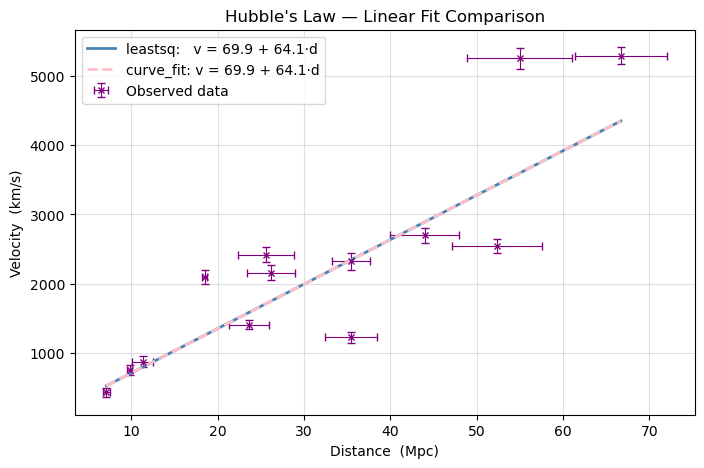

In [22]:
# q 7.10

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

# d(Mpc)    v(km/s)    error in d    error in v

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

# Using scipy.optimize.leastsq() with the consideration of velocity uncertainties to find the most optimal parameters. 
data = np.asarray(data).reshape(-1,4)

d = data[:, 0]        # distance  (Mpc)
v = data[:, 1]        # velocity  (km/s)
err_d = data[:, 2]    # uncertainty in d
err_v = data[:, 3]    # uncertainty in v 


# Linear model:  v = a + b*d 
def model(d, a, b):
    return a + b * d

# Method 1: scipy.optimize.leastsq()
# leastsq minimises sum(residuals**2); dividing by err_v weights each point
def residuals(params, data):
    a, b = params
    d_ = data[:, 0]
    v_ = data[:, 1]
    err_v_ = data[:, 3]
    return (v_ - model(d_, a, b)) / err_v_   # weighted residuals

params0 = [0.0, 70.0]              # initial guess [a, b]
result  = leastsq(residuals, params0, args=(data,), full_output=1)

a_ls, b_ls = result[0]
print("leastsq")
print(f" a = {a_ls:.2f} km/s")
print(f" b = {b_ls:.2f} km/s/Mpc (Hubble constant H0)")

# Method 2: scipy.optimize.curve_fit() 
# sigma=err_v passes velocity uncertainties; absolute_sigma=True treats them
# as true 1-sigma errors so the covariance matrix(pcov) is in physical units
beta, pcov = curve_fit(model, d, v, p0=params0, sigma=err_v, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))          # -> Calculate uncertainties (1-sigma uncertainties on params)

a_cf, b_cf = beta
print("curve_fit")
print(f" a = {a_cf:.2f} ± {perr[0]:.2f} km/s")
print(f" b = {b_cf:.2f} ± {perr[1]:.2f} km/s/Mpc (Hubble constant H0)")


# Plot 
d_fit = np.linspace(d.min(), d.max(), 300)

plt.figure(figsize=(8, 5))

# Data with error bars
plt.errorbar(d, v, yerr=err_v, xerr=err_d, fmt='x', color='purple', markersize=5, capsize=3, elinewidth=0.8, label='Observed data')

# leastsq fit
plt.plot(d_fit, model(d_fit, a_ls, b_ls), color='steelblue', linewidth=2, label=f'leastsq:   v = {a_ls:.1f} + {b_ls:.1f}·d')

# curve_fit fit
plt.plot(d_fit, model(d_fit, a_cf, b_cf), color='pink', linewidth=2, linestyle='--', label=f'curve_fit: v = {a_cf:.1f} + {b_cf:.1f}·d')

plt.xlabel('Distance  (Mpc)')
plt.ylabel('Velocity  (km/s)')
plt.title("Hubble's Law — Linear Fit Comparison")
plt.legend()
plt.grid(True, alpha=0.4)

plt.show()

In [ ]:
# q 7.14 Github